Здесь я экспериментирую с feature extraction. Я и тренирую здесь простые модели, но только для оценки полезности признаков, разработкой собственно модели можно будет заняться только позднее.

In [1]:
import polars as pl
dataset = pl.read_csv(
    '../data/processed/train.csv'
)


In [2]:
SEED = 42


In [3]:
dataset.columns


['StimSite',
 'Stimulus',
 'RT_start',
 'Response_annot',
 'Response_transcription_annot',
 'Error_type_annot',
 'error_type_label']

In [4]:
dataset_0 = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'Response_transcription_annot',
    'error_type_label'
    ]]

dataset_0[['RT_start']] = dataset_0[['RT_start']]\
                          .fill_null(strategy='zero')

dataset_0[['Response_annot']] = dataset_0[['Response_annot']]\
                        .fill_null('')

dataset_0[['Response_transcription_annot']] =\
      dataset_0[['Response_transcription_annot']].fill_null('')

# мы не хотим получать подсказки в виде #нрзб# и прочих особенностей
# разметки в транскрипте, т. к. они не всегда могут быть доступны
dataset_0 = dataset_0.with_columns(
    pl.col('Response_annot').str.to_lowercase()\
        .str.replace_all(r'[^а-яё ]', '')\
        .str.replace_all('нрзб', '')
)


Различные способы заполнения слабо влияют на метрики по результатам части 1, но при заполнении нулями метрики для классов, которые ожидаемо выявляются по признаку `RT_start`, оказываются немного выше.

# 1. Длина ответа относительно длины стимула

In [5]:
dataset_1 = dataset_0.with_columns(
                            (pl.col('Response_annot').str.len_chars() /
                            pl.col('Stimulus').str.len_chars())\
                            .fill_null(0)\
                            .alias('relative_length')
                            )


In [6]:
from json import load

error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
print(*error_type_ids.items(), sep='\n')
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


('нет', 0)
('speech arrest', 1)
('аномия', 2)
('дизартрия', 3)
('задержка', 4)
('поиск слова', 5)
('семантическая парафазия', 6)
('фонетическая парафазия', 7)


In [7]:
X = dataset_1[['relative_length', 'RT_start']]
y = dataset_1['error_type_label']


In [8]:
from sklearn.tree import DecisionTreeClassifier

basic_model = DecisionTreeClassifier(random_state=SEED, max_depth=10)


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score,\
                                                    confusion_matrix
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks
import numpy as np

def evaluate(X, y: pl.Series, estimator: Pipeline = Pipeline([
            ('classifier', basic_model)])
        ):
    # relative_length и RT_start — разного масштаба, для
    # линейных моделей здесь был бы скейлер
    k = 5
    stratified_k_fold = StratifiedKFold(n_splits = k, # test 20%
                                        shuffle = True,
                                        random_state=SEED)
    number_of_classes = y.n_unique()
    classes_met = y.unique().sort()
    error_type_ids_to_names_ = [name for i, name
                                in enumerate(error_type_ids_to_names)
                                if i in classes_met]

    f1s = np.zeros((k, number_of_classes))
    precisions = f1s.copy()
    recalls = f1s.copy()
    confusion_matrices = np.zeros((k, number_of_classes, 
                                   number_of_classes))
    
    for i, (train_mask, test_mask) in\
                    enumerate(stratified_k_fold.split(X, y)):
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        estimator.fit(X_train, y_train)
        predictions = estimator.predict(X_test)
        f1s[i] = f1_score(y_test, predictions, average=None)
        precisions[i] = precision_score(y_test, predictions,
                                         average=None)
        recalls[i] = recall_score(y_test, predictions, average=None)
        confusion_matrices[i] = confusion_matrix(y_test, predictions)

    np.set_printoptions(suppress=True)

    def _tabs(cell):
        return cell + '\t' * (3 - len(cell) // 8)

    print('Класс\t\t\tPrec.\tRec.\tF1')
    print(*('%s%.4f\t%.4f\t%.4f' % (_tabs(name),
             precision.item(),
             recall.item(),
             f1.item())
            for name, precision, recall, f1
            in zip(error_type_ids_to_names_,
                   precisions.mean(axis=0),
                   recalls.mean(axis=0),
                   f1s.mean(axis=0))), 
            sep='\n')
    
    confusion_matrix_mean = confusion_matrices.mean(axis = 0).round(2)
    confusion_matrix_normalized = confusion_matrix_mean / \
                    confusion_matrix_mean.max(axis=1, keepdims=True)
    imshow(confusion_matrix_normalized)
    ylabel('Истина')
    xlabel('Предсказание')
    yticks(range(number_of_classes), error_type_ids_to_names_)
    xticks(range(number_of_classes), error_type_ids_to_names_, 
           rotation=45)
    return f1s.mean(axis=0), precisions.mean(axis=0), recalls.mean(axis=0)



In [10]:
# import re

# def get_replacement_pairs(**kwargs):
#     stimulus = kwargs['Stimulus']
#     response = kwargs['Response_annot']
#     return [(stimulus[i], response[j])
#             for tag, i, j in Levenshtein.editops(stimulus, 
#                                             response)
#             if tag == 'replace']


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Класс			Prec.	Rec.	F1
нет			0.9241	0.9852	0.9537
speech arrest		0.5050	1.0000	0.6681
аномия			0.8257	0.6240	0.7059
дизартрия		0.2514	0.0516	0.0849
задержка		0.5970	0.3549	0.4446
поиск слова		0.3429	0.1197	0.1647
семантическая парафазия	0.0286	0.0071	0.0114
фонетическая парафазия	0.0844	0.0118	0.0205


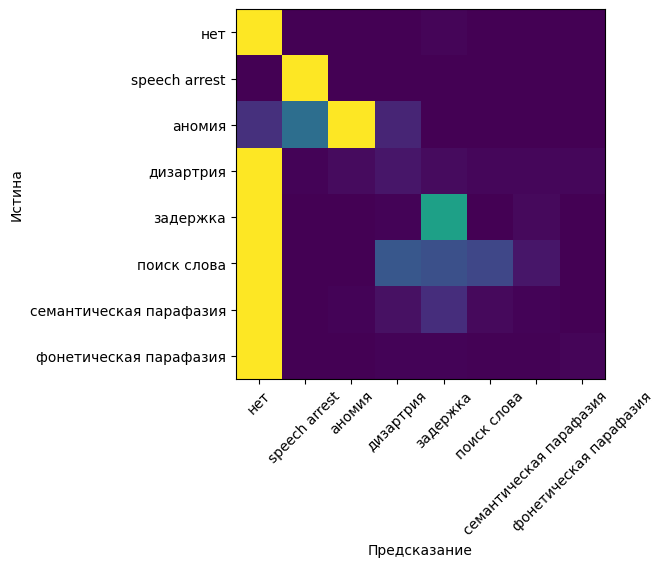

In [11]:
_ = evaluate(X, y)


# 2. Расстояние Левенштейна между стимулом и ответом

## Простейший случай
Сначала посмотрим на полезность доли вставок, удалений и замен. Доли, потому что стимулы могут быть разной длины, и для них будет в разной степени критично одно и то же абсолютное количество замен.

In [12]:
from rapidfuzz.distance import Levenshtein

def indelrep(stimulus, response) -> tuple[int, int, int]:
    edit_operations = Levenshtein.editops(stimulus, response)
    operation_counts = [0] * 3
    operation_ids = dict(zip(['insert', 'delete', 'replace'], range(3)))
    for tag, _, _ in edit_operations:
        operation_counts[operation_ids[tag]] += 1
    return tuple(count / len(stimulus) for count in operation_counts)

print(indelrep('роман', 'роамн'))


(0.2, 0.2, 0.0)


In [13]:
dataset_2 = dataset_1

In [14]:
dataset_2 = dataset_2.with_columns(
    pl.struct(['Stimulus', 'Response_annot'])
    .map_elements(
        lambda s: indelrep(s['Stimulus'], s['Response_annot']), 
        return_dtype=pl.Struct([
            pl.Field('insertions', pl.Float64),
            pl.Field('deletions', pl.Float64),
            pl.Field('replacements', pl.Float64)
        ])
    )
    .alias('edit_distance_components')
).unnest('edit_distance_components')


Класс			Prec.	Rec.	F1
нет			0.9322	0.9857	0.9582
speech arrest		0.5050	1.0000	0.6681
аномия			0.8775	0.6444	0.7352
дизартрия		0.3203	0.0806	0.1281
задержка		0.6328	0.3676	0.4644
поиск слова		0.4910	0.2197	0.3007
семантическая парафазия	0.3017	0.1294	0.1774
фонетическая парафазия	0.5654	0.2323	0.3233


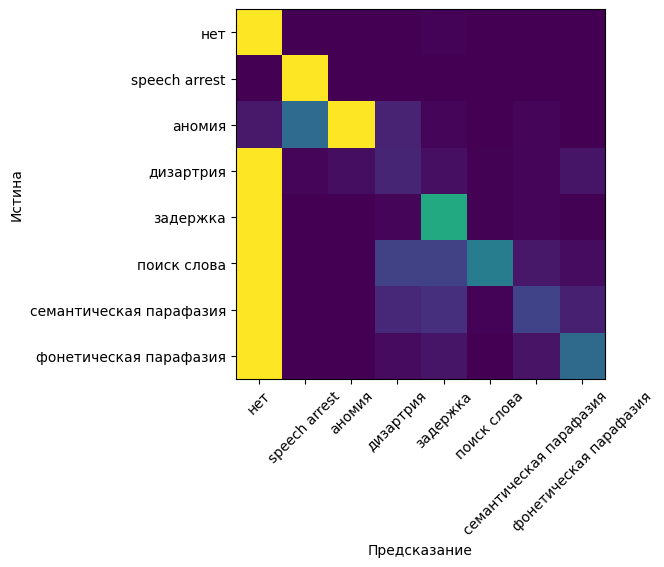

In [15]:
X = dataset_2[['RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']
_ = evaluate(X, y)


Отдельно проверим поинты, для которых есть транскрипция.

In [16]:
dataset_2_t = dataset_2\
    .filter(pl.col('Response_transcription_annot').str.len_chars() > 0)\
    .with_columns(
    pl.struct(['Stimulus', 'Response_transcription_annot'])
    .map_elements(
        lambda s: indelrep(s['Stimulus'],
                           s['Response_transcription_annot']), 
        return_dtype=pl.Struct([
            pl.Field('insertions_transcription', pl.Float64),
            pl.Field('deletions_transcription', pl.Float64),
            pl.Field('replacements_transcription', pl.Float64)
        ])
    )
    .alias('edit_distance_components_transcription')
).unnest('edit_distance_components_transcription')


Класс			Prec.	Rec.	F1
нет			0.2278	0.0945	0.1282
аномия			0.7723	0.8464	0.8024
дизартрия		0.4231	0.4336	0.4256
задержка		0.7150	0.7972	0.7528
поиск слова		0.2264	0.1945	0.1990
семантическая парафазия	0.2562	0.2543	0.2489
фонетическая парафазия	0.5313	0.3952	0.4524


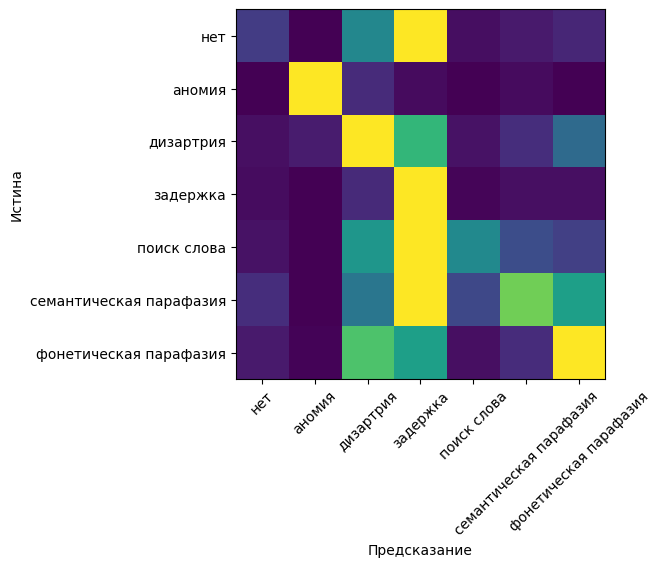

In [17]:
X = dataset_2_t[['RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2_t['error_type_label']
_ = evaluate(X, y)


## Отдельные замены

Найдём самые частотные замены, оставим только их количество для каждого поинта, натренируем модель и посмотрим, как она справится. Тут возникнет две проблемы:
 + Матрица признаков будет разреженной; нужно будет или поднять порог частотности, или выбрать классификатор, который хорошо с таким работает.
 + Нужно писать свой трансформер для sklearn, потому что считать частотность по-хорошему надо каждый раз на тренировочной выборке, а не на датасете целиком, чтобы избежать утечки распределения. Это будет полезно позже, когда все операции над датасетом надо будет проводить в пайплайне.

In [18]:
def get_replacement_pairs(stimulus, response):
    return [(stimulus[i], response[j])
            for tag, i, j in Levenshtein.editops(stimulus, 
                                            response)
            if tag == 'replace']


In [19]:
get_replacement_pairs('штегрусым', 'это штеграсым')


[('у', 'а')]

In [20]:
from numpy import ndarray
from sklearn.base import BaseEstimator, TransformerMixin
from collections import Counter

class ReplacementCounter(BaseEstimator, TransformerMixin):
    def __init__(self, columns, max_features=10000,
                 use_transcription=False):
        self.columns = columns
        self.max_features = max_features
        self.use_transcription = use_transcription

    def _counts(self, X: pl.DataFrame | np.ndarray):
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок')
        new_rows = []
        for row in X\
            .with_row_index('id')\
            .to_dicts():
            pairs = Counter()
            pairs.update([f'replacements_{l1}_{l2}' \
                        for l1, l2 in get_replacement_pairs(
                                row['Stimulus'], row['Response_annot']
                            )])
            if self.use_transcription:
                pairs.update([f'replacements_{l1}_{l2}_t' \
                            for l1, l2 in get_replacement_pairs(
                                    row['Stimulus'],
                                    row['Response_transcription_annot']
                                )])
            row.update(pairs.items())
            new_rows.append(row)
        return pl.from_dicts(new_rows)
    
    def fit(self, X: pl.DataFrame | np.ndarray, y = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.columns)
        columns_before = X.columns
        columns_to_pass = ['Stimulus',
                            'Response_annot']
        if self.use_transcription:
            columns_to_pass += ['Response_transcription_annot']
        X = self._counts(X[columns_to_pass])
        self.top_columns = \
            X.select(pl.all()\
                .exclude(pl.String)\
                .sum()
            )\
            .unpivot()\
            .sort('value', descending=True)\
            .head(self.max_features + 1)
        # print(self.top_columns)
        self.feature_columns = self.top_columns\
            .get_column('variable')\
            .to_list()
        self.columns_to_leave = columns_before + self.feature_columns
        return self
    def transform(self, X):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.columns)
        counts = self._counts(X)
        counts = counts.with_columns(
                [pl.lit(None, dtype=pl.Int64).alias(c) 
                for c in self.feature_columns
                if c not in counts.columns]
            )\
            .select(self.feature_columns)
        # print(counts)
        return X.hstack(counts.drop('id'))\
            .fill_null(0)\
            .drop(pl.selectors.string())


In [21]:
replacement_counter = ReplacementCounter(dataset_2.columns)
replacement_counter.fit(dataset_2)
replacement_counter.transform(dataset_2[:20])


RT_start,error_type_label,relative_length,insertions,deletions,replacements,replacements_р_т,replacements_е_ё,replacements_а_и,replacements_к_т,replacements_е_и,replacements_к_н,replacements_я_е,replacements_е_,replacements_и_ы,replacements_р_о,replacements_б_ш,replacements_ю_а,replacements_л_т,replacements_б_,replacements_о_а,replacements_о_е,replacements_у_о,replacements_п_т,replacements_и_о,replacements_к_э,replacements_я_о,replacements_г_,replacements_к_б,replacements_у_ж,replacements_ш_а,replacements_к_в,replacements_у_ц,replacements_в_о,replacements_а_,replacements_а_м,replacements_к_е,replacements_ц_т,replacements_с_,replacements_с_л,replacements_п_,replacements_а_э,replacements_о_т,replacements_б_л,replacements_в_э,replacements_л_ж,replacements_у_к,replacements_ш_м,replacements_в_р,replacements_н_о,replacements_д_,replacements_ж_к,replacements_к_ш,replacements_и_б,replacements_б_з,replacements_я_к,replacements_м_и,replacements_с_к,replacements_д_э,replacements_о_э
i64,i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
711,0,1.5,0.5,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
744,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
681,0,1.8,0.8,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1333,0,1.0,0.125,0.125,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1265,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
701,0,1.666667,0.666667,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
777,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
787,0,2.0,1.0,0.0,0.833333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0


Класс			Prec.	Rec.	F1
нет			0.9346	0.9825	0.9580
speech arrest		0.5050	1.0000	0.6681
аномия			0.8716	0.7205	0.7866
дизартрия		0.3498	0.0710	0.1167
задержка		0.6399	0.3803	0.4746
поиск слова		0.4610	0.2212	0.2963
семантическая парафазия	0.2206	0.0857	0.1228
фонетическая парафазия	0.4497	0.3544	0.3849


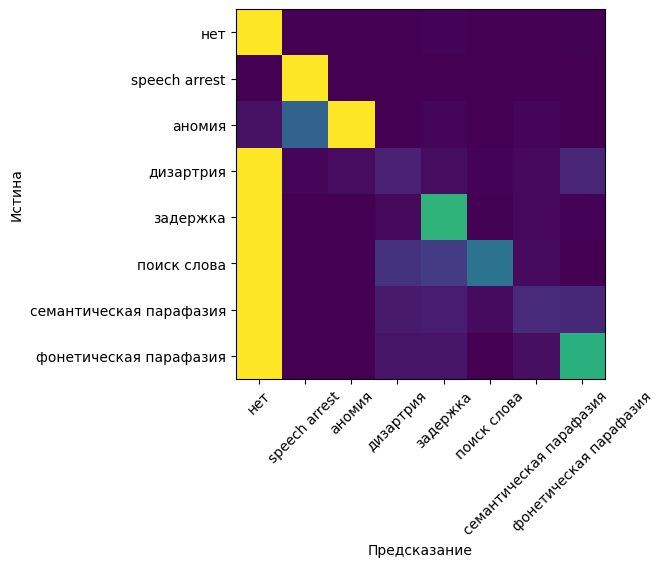

In [22]:
new_pipeline = Pipeline([
        ('counter', ReplacementCounter(dataset_2.columns)),
        ('classifier', basic_model)
])

X = dataset_2[['Stimulus', 'Response_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']

_ = evaluate(X, y, new_pipeline)


Метрика для фонетической парафазии ожидаемо заметно поднялась.

## Отдельные замены, вставки и удаления

In [23]:
class EditopsCounter(ReplacementCounter):
    @staticmethod
    def _get_editop_string(type_: str,
                            i_source: int, 
                            i_destination: int,
                            source: str,
                            destination: str) -> str:
            if type_ == 'delete':
                return f'{type_}_{source[i_source]}'
            if type_ == 'insert':
                return f'{type_}_{destination[i_destination]}'
            return f'{type_}_{source[i_source]}'\
                   f'_{destination[i_destination]}'
    
    def _counts(self, X):
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок')
        new_rows = []
        for row in X\
            .with_row_index('id')\
            .to_dicts():
            pairs = Counter()
            # здесь был очень большой баг
            pairs.update([self._get_editop_string(
                            type_, i1, i2,
                            row['Stimulus'],
                            row['Response_annot']) \
                        for type_, i1, i2 in Levenshtein.editops(
                            row['Stimulus'],
                            row['Response_annot'])]
                        )
            
            if self.use_transcription:
                pairs.update([self._get_editop_string(
                                type_, i1, i2,
                                row['Stimulus'],
                                row['Response_transcription_annot'])\
                                +'_t' \
                            for type_, i1, i2 in Levenshtein.editops(
                                row['Stimulus'],
                                row['Response_transcription_annot'])]
                            )
            row.update(pairs.items())
            new_rows.append(row)
        return pl.from_dicts(new_rows, infer_schema_length=2**32)


Класс			Prec.	Rec.	F1
нет			0.9387	0.9896	0.9635
speech arrest		0.9267	0.8000	0.8339
аномия			0.8518	0.9035	0.8749
дизартрия		0.3267	0.0419	0.0741
задержка		0.7514	0.4439	0.5558
поиск слова		0.5826	0.4758	0.5208
семантическая парафазия	0.3984	0.1725	0.2312
фонетическая парафазия	0.6473	0.3897	0.4775


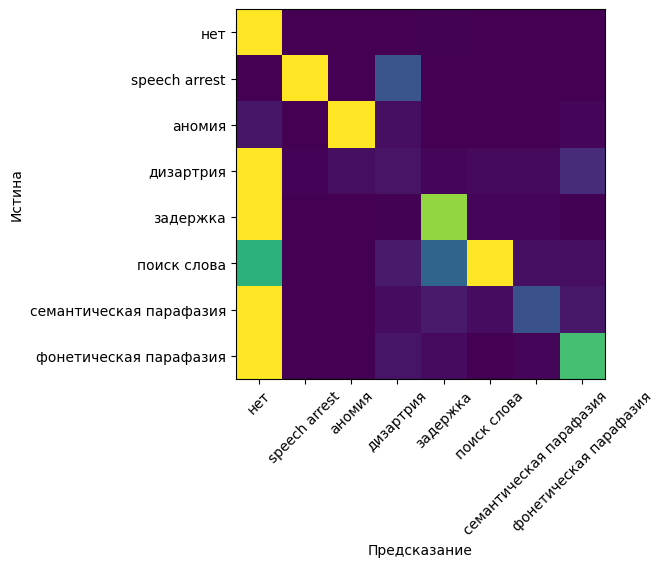

In [24]:
X = dataset_2[['Stimulus', 'Response_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']

new_pipeline = Pipeline([
        ('counter', EditopsCounter(X.columns)),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline)


Класс			Prec.	Rec.	F1
нет			0.1045	0.0982	0.1007
аномия			0.8451	0.8500	0.8372
дизартрия		0.6215	0.5733	0.5929
задержка		0.8236	0.8313	0.8269
поиск слова		0.6311	0.4982	0.5448
семантическая парафазия	0.4286	0.3657	0.3912
фонетическая парафазия	0.6157	0.7163	0.6598


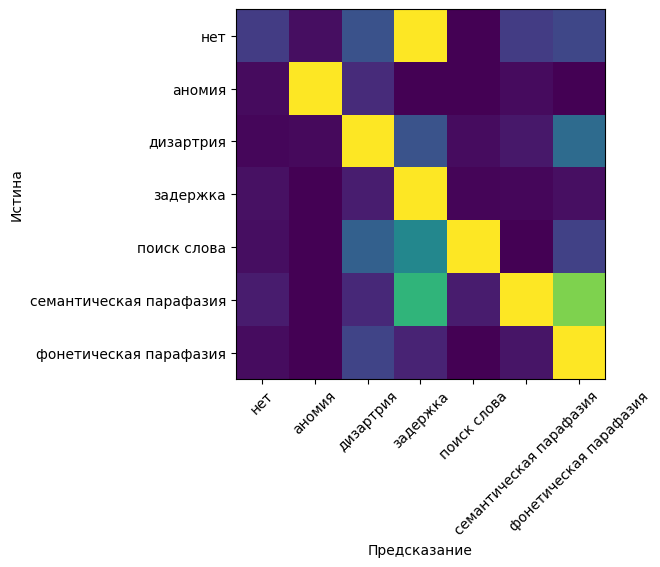

In [25]:
X = dataset_2_t[['Stimulus', 'Response_annot',
                 'Response_transcription_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements',
               'insertions_transcription',
               'deletions_transcription',
               'replacements_transcription']]
y = dataset_2_t['error_type_label']

new_pipeline = Pipeline([
        ('counter', EditopsCounter(X.columns, use_transcription=True)),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline)


### Рефакторинг

Рефакторинг всего, что есть выше, в `BaseEstimator`.

In [26]:
from collections.abc import Sequence
from typing import Any

from sklearn.exceptions import NotFittedError

class FeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, column_names: Sequence[str] = [],
                 max_editops: int = 10000,
                 force_use_transcription: bool = False):
        '''
        :param column_names: Метки столбцов набора данных, если
            подаётся стуктура данных без них.

        :param max_editops: Максимальное количество выдаваемых в
            качестве признаков операций редактирования.

        :param force_use_transcription: Использовать ли транскрипцию при
            её остсутствии у части записей. Если `True`, вместо 
            отсутствующих транскрипций используются пустые строки. Если 
            `False`, транскрипции используются только при их наличии у
            всех записей.
        '''
        self.fit_ = False
        self.column_names = column_names
        self.max_editops = max_editops
        self.force_use_transcription = force_use_transcription
        self.use_transcription = self.force_use_transcription

    def _clean(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Подготавливает колонки с исходными данными: заполняет пропуски
        и очищает `'Response_annot'` от небукв и нрзб.
        '''
        return X\
            .with_columns( # заполнение пропусков
                pl.col('RT_start').fill_null(strategy='zero'),
                pl.col('Response_annot')\
                    .fill_null('')\
                    # очистка
                    .str.to_lowercase()\
                    .str.replace_all(r'[^а-яё ]', '')\
                    .str.replace_all('нрзб', ''),
                pl.col('Response_transcription_annot').fill_null('')
            )

    
    def _get_relative_lengths(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Рассчитать длины ответа и транскрипции ответа по отношению к
        стимулу.

        :param X: Датафрейм с колонками `'Stimulus'`,
          `'Response_annot'` и `'Response_transcription_annot'`.

        :returns: Новый датафрейм с единственной колонкой 
          `'relative_length'` или с двумя — с ней и с 
          `'relative_length_transcription'`.
        '''
        X = X\
            .with_columns( # относительная длина
                            (pl.col('Response_annot').str.len_chars()/
                            pl.col('Stimulus').str.len_chars())\
                        .fill_null(0)\
                        .alias('relative_length')
            )
        selection: list[str] = ['relative_length']
        if self.use_transcription:
            X = X.with_columns( # относительная длина транскрипции
                (pl.col('Response_transcription_annot').str.len_chars()/
                pl.col('Stimulus').str.len_chars())\
                .fill_null(0)\
                .alias('relative_length_transcription')
            )
            selection.append('relative_length_transcription')
        return X[selection]

    @staticmethod
    def _get_editop_string(type_: str,
                               i_source: int, 
                               i_destination: int,
                               source: str,
                               destination: str) -> str:
            if type_ == 'delete':
                return f'{type_}_{source[i_source]}'
            if type_ == 'insert':
                return f'{type_}_{destination[i_destination]}'
            return f'{type_}_{source[i_source]}'\
                   f'_{destination[i_destination]}'

    def _editop_counts(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Считает количество операций редактирования для каждой пары
        символов.

        :param X: Датафрейм со столбцами `'Stimulus'`,
         `'Response_annot'` и, если нужно,
         `'Response_transcription_annot'`

        :returns: Новый датафрейм со столбцами для каждой 
         операции редактирования с каждой парой символов.
        '''
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок для подсчёта отдель'\
                            'ных операций редактирования.')
        new_rows: list[dict[str, int]] = []
        
        for row in X\
            .to_dicts(): # iter_rows()
            pairs: Counter[str] = Counter()
            pairs.update([self._get_editop_string(
                            type_, i1, i2,
                            row['Stimulus'],
                            row['Response_annot']) \
                        for type_, i1, i2 in Levenshtein.editops(
                            row['Stimulus'],
                            row['Response_annot'])]
                        )
            
            if self.use_transcription:
                pairs.update(['T' + self._get_editop_string(
                                type_, i1, i2,
                                row['Stimulus'],
                                row['Response_transcription_annot'])\
                            for type_, i1, i2 in Levenshtein.editops(
                                row['Stimulus'],
                                row['Response_transcription_annot'])]
                            )
                
            new_rows.append(dict(pairs))
        # print(new_rows[319])
        output = pl.from_dicts(new_rows,
                               infer_schema_length=2**32)
        # display(output[319])
        # display(output[319].sum_horizontal())
        # output = output.fill_null(0)
        # display(output[319])
        # display(output[319].sum_horizontal())
        return output

    def fit(self, X: pl.DataFrame | np.ndarray, y: Any = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)

        self.use_transcription = self.force_use_transcription or not\
            X.get_column('Response_transcription_annot').is_null().any()
        X = self._clean(X)

        # определение самых частотных операций в датасете, на котором
        # преобразователь фиттится
        X = self._editop_counts(X)
        self.top_editop_columns: list[str] = \
                    X.select(pl.all()\
                        .exclude(pl.String)\
                        .sum()
                    )\
                    .unpivot()\
                    .sort('value', descending=True)\
                    .head(self.max_editops)\
                    .get_column('variable')\
                    .to_list()

        self.fit_ = True
        return self

    def transform(self, X: pl.DataFrame | np.ndarray):
        if not self.fit_:
            raise NotFittedError
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)

        X = self._clean(X)
        relative_lengths = self._get_relative_lengths(X)

        counts = self._editop_counts(X)

        
        # нормализованные количества операций
        prefixes = ['Tdelete', 'Tinsert', 'Treplace',
                    'delete', 'insert', 'replace']
        stimulus_lengths = X.get_column('Stimulus').str.len_chars()
        normalized_total_editops = []
        for prefix in prefixes:
            columns_to_sum = [c
                           for c in counts.columns
                           if c.startswith(f"{prefix}_")]
            if columns_to_sum:
                column = \
                (counts.select(columns_to_sum)\
                        .sum_horizontal() /
                          stimulus_lengths)\
                    .alias(prefix + '_normalized_total')
                normalized_total_editops.append(column)

        normalized_total_editops = \
            pl.DataFrame(normalized_total_editops)
        

        counts = counts.with_columns(
                [pl.lit(0, dtype=pl.Int64).alias(c) 
                for c in self.top_editop_columns
                if c not in counts.columns])\
            .select(self.top_editop_columns)

        X = pl.concat([X, relative_lengths,
                normalized_total_editops, counts], how="horizontal") \
            .drop(pl.selectors.string()) \
            .fill_null(0)
        
        return X


Класс			Prec.	Rec.	F1
нет			0.9392	0.9895	0.9637
speech arrest		0.9267	0.8000	0.8339
аномия			0.8698	0.9035	0.8844
дизартрия		0.3139	0.0387	0.0688
задержка		0.7473	0.4462	0.5568
поиск слова		0.5591	0.4758	0.5129
семантическая парафазия	0.3587	0.1722	0.2227
фонетическая парафазия	0.6474	0.3897	0.4779


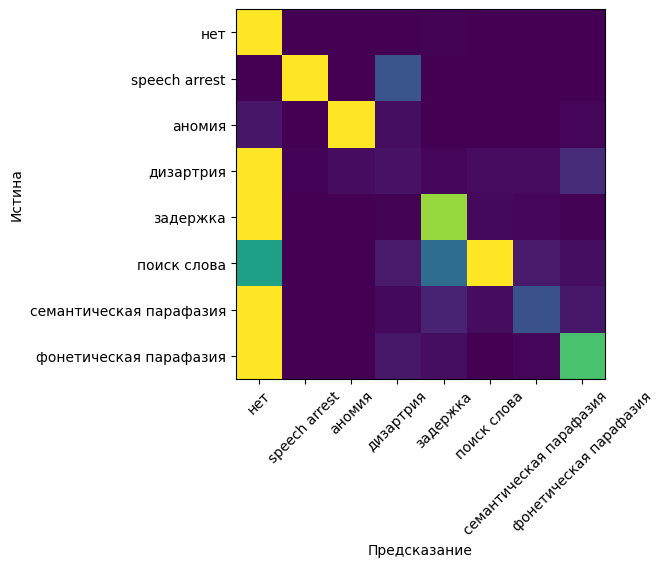

In [27]:
dataset_0_raw = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'Response_transcription_annot',
    'error_type_label'
    ]]

X = dataset_0_raw.drop('error_type_label')
y = dataset_0_raw['error_type_label']

new_pipeline_2 = Pipeline([
        ('feature_extractor', FeatureExtractor()),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline_2)



In [28]:
FeatureExtractor().fit_transform(X)


RT_start,relative_length,delete_normalized_total,insert_normalized_total,replace_normalized_total,insert_,insert_э,insert_т,insert_о,delete_ь,insert_е,delete_а,replace_а_е,delete_и,replace_р_т,replace_е_ё,insert_а,replace_а_и,insert_у,insert_п,insert_к,delete_о,insert_и,replace_к_т,delete_в,replace_е_и,insert_ь,replace_о_у,delete_т,replace_к_н,replace_я_е,insert_с,replace_е_,replace_а_ё,insert_н,replace_и_ы,replace_р_о,…,replace_а_с,replace_с_я,replace_т_г,replace_ч_о,replace_м_щ,replace_д_р,replace_ю_у,replace_е_ш,replace_х_г,replace_н_е,replace_м_ж,replace_к_ф,replace_ч_г,replace_л_ъ,replace_ф_ш,replace_л_з,replace_п_ф,replace_о_м,replace_д_н,replace_ч_ь,replace_е_ю,replace_о_я,replace_ь_д,replace_а_ъ,replace_у_м,replace_в_с,replace_д_г,replace_п_и,replace_л_е,replace_я_р,replace_я_п,replace_б_у,replace_т_я,replace_у_ю,replace_ж_л,replace_к_я,replace_ф_ц
i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
711,1.5,0.0,0.5,0.0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
744,1.571429,0.0,0.571429,0.0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
681,1.8,0.0,0.8,0.0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1333,1.0,0.125,0.125,0.0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1265,1.571429,0.0,0.571429,0.0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
958,1.444444,0.0,0.444444,0.0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
632,1.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1201,1.0,0.125,0.125,0.0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Класс			Prec.	Rec.	F1
нет			0.1222	0.1182	0.1190
аномия			0.9214	0.8500	0.8798
дизартрия		0.6198	0.5769	0.5949
задержка		0.8251	0.8406	0.8326
поиск слова		0.6570	0.5382	0.5677
семантическая парафазия	0.3923	0.3381	0.3554
фонетическая парафазия	0.6170	0.7000	0.6525


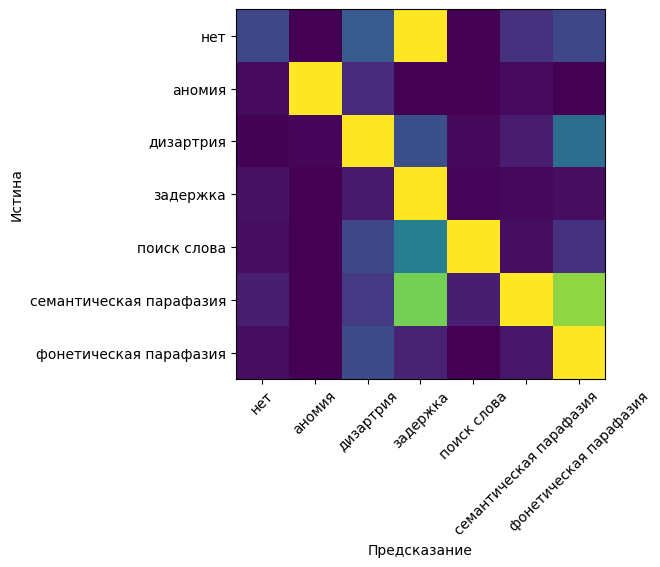

In [29]:
dataset_0_raw = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'Response_transcription_annot',
    'error_type_label'
    ]].filter(pl.col('Response_transcription_annot').is_not_null())

X = dataset_0_raw.drop('error_type_label')
y = dataset_0_raw['error_type_label']

new_pipeline_2 = Pipeline([
        ('feature_extractor', FeatureExtractor()),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline_2)



# Положение ответов в языке

До этого я анализировал только то, как ответ соотносится со стимулом. Тем не менее, семантическую и фонетическую парафазию нельзя определить в отрыве от всего остального языка, в частности, так не делалось при человеческой разметке.

## Формальная близость к настоящим словам

Предполагается, что если ответ формально близок к какому-либо существующему слову и далёк от стимула — то это семантическая парафазия, если ближе к стимулу — то фонетическая.

Будем использовать наиболее частотные существительные и глагольные формы по Araneum Russicum III Maximum (Russian, 19.03) 19.8 G. Будет определяться расстояние Левенштейна между ответом, стимулом и ближайшим к ответу словом из корпуса. Также учитывается разность логарифмов частотностей кандидата в ответы и стимула. Это нужно, чтобы исключить ложное попадание в слишком редкое или слишком частотное слово при фактической фонетической парафазии; также предполагается, что при семантической парафазии заменяющее слово будет примерно так же частотно, как стимул.

In [30]:
aranea_word_list = pl.read_csv('../data/word_frequencies/'
                               'AranRusi_a.tsv',
                               separator='\t')\
                    .with_columns(pl.col('Frequency')\
                                    .log(base=2)\
                                    .alias('log_Frequency'),
                                  pl.col('word')\
                                    .fill_null('')\
                                    .str.to_lowercase()\
                                    .str.replace_all(r'[^а-яё ]', '')\
                                    .str.replace_all('нрзб', ''))\
                        .filter(pl.col('word').str.len_chars() > 0)\
                        .unique(pl.col('word'))


## Оптимизация

Тут нужно посчитать медленным способом на какой-то подвыборке на которой это вообще получится, затем на той же быстрым, затем посчитать метрики.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 478148

word_list_vectorizer = CountVectorizer(analyzer='char', dtype=np.int8)
word_list_vectors = word_list_vectorizer.fit_transform(
    aranea_word_list['word'])

# 494324 3.5


In [ ]:
queries = pl.concat([dataset_0['Response_annot'],\
                            dataset_0['Stimulus']]).unique()
# 493224


In [ ]:
from rapidfuzz.process import cdist

golden_distances = cdist(queries,
                    aranea_word_list['word'],
                    scorer=Levenshtein.distance,
                    dtype=np.int8)
# 910076 16.6

In [34]:
k = 5

In [ ]:
golden_topk_indices = np.sort(golden_distances\
                .argpartition(axis=1, kth=k-1)[:, :k],
                axis=1)

# 910084 5.3


In [93]:
golden_topk_indices.shape

(1012, 20)

In [84]:
example_index = 123

In [ ]:
golden_topk_indices[example_index]

array([196861, 263392, 279774, 323063, 361380])

In [ ]:
golden_distances[example_index, golden_topk_indices[example_index]]

array([6, 5, 4, 6, 6], dtype=int8)

In [ ]:
queries[example_index]

'это  бинокль'

In [ ]:
aranea_word_list[golden_topk_indices[example_index]]

word,Frequency,log_Frequency
str,i64,f64
"""бинокли""",491,8.939579
"""бинокль""",266,8.055282
"""фотобинокль""",2,1.0
"""атомобиль""",4,2.0
"""эмоболь""",2,1.0


In [ ]:
query_vectors = word_list_vectorizer.transform(queries)
# 910088

In [94]:
from sklearn.neighbors import NearestNeighbors


nearest_neighbors = NearestNeighbors(metric='manhattan', n_neighbors=k)\
                        .fit(word_list_vectors)
# 926936

In [95]:
nn_candidates = nearest_neighbors.kneighbors(query_vectors)
# 927020 15.7
# 927024 15.2

In [96]:
nn_candidates[0][example_index]

array([2., 2., 2., 2., 3.])

In [97]:
nn_candidates[1][example_index]

array([ 90249, 202911, 348832, 104741,   7642])

In [99]:
aranea_word_list[nn_candidates[1][example_index]]

word,Frequency,log_Frequency
str,i64,f64
"""билоконь""",5,2.321928
"""болотник""",14,3.807355
"""котильон""",11,3.459432
"""ботильон""",3,1.584963
"""биоконтроль""",75,6.228819


Метрика для оценки качества найденных кандидатов

In [253]:
def metric(y_true: np.ndarray, y_pred: np.ndarray, k: int = 5)\
      -> np.ndarray:
    # y_true = np.sort(y_true, axis=-1)
    y_pred = np.partition(y_pred, kth=k - 1, axis=-1)
    mask = (y_pred[:, :k] <= y_true[:, :k])
    first_false = np.argmin(mask, axis=-1)
    all_true = np.all(mask, axis=-1)
    return np.where(all_true, k, first_false) / k

In [254]:
metric_test_true = np.array([[1, 2, 3, 4, 5],
                             [1, 2, 3, 4, 5],
                             [1, 2, 3, 4, 5]])

metric_test_pred = np.array([[1, 2, 3, 4, 5],
                             [2, 3, 4, 4, 5],
                             [1, 2, 4, 4, 5]])


In [255]:
metric(metric_test_true, metric_test_pred)

array([1. , 0. , 0.4])

In [265]:
nn_candidate_indices = nearest_neighbors.kneighbors(query_vectors,     
                                                n_neighbors=1000,
                                                return_distance=False)


In [188]:
golden_distances_sorted = np.sort(golden_distances,
                                    axis=1)

In [266]:
golden_distances_arranged_by_nn = np.take_along_axis(
    golden_distances, indices=nn_candidate_indices, axis=1
)

In [206]:
golden_distances.shape

(1012, 421238)

In [267]:
nn_candidate_indices.shape

(1012, 1000)

In [287]:
from tqdm import tqdm
metric_means: list[float] = []

for k_dynamic in tqdm(range(5, 1000)):
    metric_means.append(metric(golden_distances_sorted[:, :k_dynamic],
                       golden_distances_arranged_by_nn[:, :k_dynamic], 
                       k=3)\
            .mean())


100%|██████████| 995/995 [00:03<00:00, 290.60it/s]


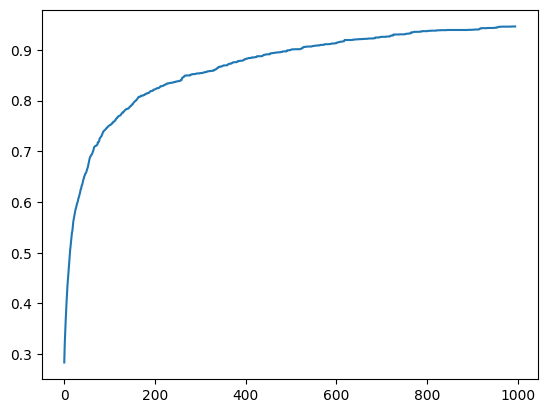

In [288]:
from matplotlib.pyplot import plot, margins, xlabel

plot(metric_means)
# margins(x=0, y=0) 


## Интеграция в feature extractor

In [ ]:
from collections.abc import Sequence
from typing import Any

from sklearn.exceptions import NotFittedError

class FeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, column_names: Sequence[str] = [],
                 *,
                 max_editops: int = 10000,
                 force_use_transcription: bool = False,
                 word_list_path: str = '../data/word_frequencies/'
                                       'AranRusi_a.tsv',
                 word_list_cutoff: int = 30000,
                 word_list_log_base: float = 2,
                 word_list_log_difference_power: float = 0):
        '''
        :param column_names: Метки столбцов набора данных, если
            подаётся стуктура данных без них.

        :param max_editops: Максимальное количество выдаваемых в
            качестве признаков операций редактирования.

        :param force_use_transcription: Использовать ли транскрипцию при
            её остсутствии у части записей. Если `True`, вместо 
            отсутствующих транскрипций используются пустые строки. Если 
            `False`, транскрипции используются только при их наличии у
            всех записей.

        :param word_list_path: Путь к TSV файлу, содержащему частотный
            список слов в виде колонок `'words'` со словами и 
            `'Frequency'` — с абсолютной частотностью.

        :param word_list_cutoff: Сколько первых строк частотного списка
            слов использовать.

        :param word_list_log_base: Основание логарифма частотности
            стимула и логарифма частотности слова, близкого к ответу.

        :param word_list_log_difference_exponent: Степень модуля 
            разности логарифма частотности стимула и логарифма 
            частотности слова, близкого к ответу, в значении метрики.
        '''
        self.fit_ = False
        self.column_names = column_names
        self.max_editops = max_editops
        self.force_use_transcription = force_use_transcription
        self.use_transcription = self.force_use_transcription

        self.word_list = pl.read_csv(word_list_path,
                               separator='\t')\
                            .sort('Frequency', descending=True)\
                            .with_columns(pl.col('Frequency')\
                                    .log(base=2)\
                                    .alias('log_Frequency'),
                                  pl.col('word')\
                                    .fill_null('')\
                                    .str.to_lowercase()\
                                    .str.replace_all(r'[^а-яё ]', '')\
                                    .str.replace_all('нрзб', ''))\
                        .filter(pl.col('word').str.len_chars() > 0)\
                        .unique(pl.col('word'))[:word_list_cutoff]
        
        self.word_list_log_difference_power = \
            word_list_log_difference_power

    def _clean(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Подготавливает колонки с исходными данными: заполняет пропуски
        и очищает `'Response_annot'` от небукв и нрзб.
        '''
        return X\
            .with_columns( # заполнение пропусков
                pl.col('RT_start').fill_null(strategy='zero'),
                pl.col('Response_annot')\
                    .fill_null('')\
                    # очистка
                    .str.to_lowercase()\
                    .str.replace_all(r'[^а-яё ]', '')\
                    .str.replace_all('нрзб', ''),
                pl.col('Response_transcription_annot').fill_null('')
            )

    def _get_relative_lengths(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Рассчитать длины ответа и транскрипции ответа по отношению к
        стимулу.

        :param X: Датафрейм с колонками `'Stimulus'`,
          `'Response_annot'` и `'Response_transcription_annot'`.

        :returns: Новый датафрейм с единственной колонкой 
          `'relative_length'` или с двумя — с ней и с 
          `'relative_length_transcription'`.
        '''
        X = X\
            .with_columns( # относительная длина
                            (pl.col('Response_annot').str.len_chars()/
                            pl.col('Stimulus').str.len_chars())\
                        .fill_null(0)\
                        .alias('relative_length')
            )
        selection: list[str] = ['relative_length']
        if self.use_transcription:
            X = X.with_columns( # относительная длина транскрипции
                (pl.col('Response_transcription_annot').str.len_chars()/
                pl.col('Stimulus').str.len_chars())\
                .fill_null(0)\
                .alias('relative_length_transcription')
            )
            selection.append('relative_length_transcription')
        return X[selection]

    @staticmethod
    def _get_editop_string(type_: str,
                               i_source: int, 
                               i_destination: int,
                               source: str,
                               destination: str) -> str:
            if type_ == 'delete':
                return f'{type_}_{source[i_source]}'
            if type_ == 'insert':
                return f'{type_}_{destination[i_destination]}'
            return f'{type_}_{source[i_source]}'\
                   f'_{destination[i_destination]}'

    def _editop_counts(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Считает количество операций редактирования для каждой пары
        символов.

        :param X: Датафрейм со столбцами `'Stimulus'`,
         `'Response_annot'` и, если нужно,
         `'Response_transcription_annot'`

        :returns: Новый датафрейм со столбцами для каждой 
         операции редактирования с каждой парой символов.
        '''
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок для подсчёта отдель'\
                            'ных операций редактирования.')
        new_rows: list[dict[str, int]] = []
        
        for row in X\
            .to_dicts(): # iter_rows()
            pairs: Counter[str] = Counter()
            pairs.update([self._get_editop_string(
                            type_, i1, i2,
                            row['Stimulus'],
                            row['Response_annot']) \
                        for type_, i1, i2 in Levenshtein.editops(
                            row['Stimulus'],
                            row['Response_annot'])]
                        )
            
            if self.use_transcription:
                pairs.update(['T' + self._get_editop_string(
                                type_, i1, i2,
                                row['Stimulus'],
                                row['Response_transcription_annot'])\
                            for type_, i1, i2 in Levenshtein.editops(
                                row['Stimulus'],
                                row['Response_transcription_annot'])]
                            )
                
            new_rows.append(dict(pairs))
        # print(new_rows[319])
        output = pl.from_dicts(new_rows,
                               infer_schema_length=2**32)
        # display(output[319])
        # display(output[319].sum_horizontal())
        # output = output.fill_null(0)
        # display(output[319])
        # display(output[319].sum_horizontal())
        return output

    def _distance(self, stimulus: str, transcription: str,
                  stimulus_frequency_log: float,
                  transcription_frequency_log: float
                  ) -> float:

        return (Levenshtein.distance(stimulus, transcription)\
                * (abs(stimulus_frequency_log - \
                      transcription_frequency_log)\
                    ** self.word_list_log_difference_power))\
                                / len(stimulus)

    def _get_word_list_metric(self):

        return

    def fit(self, X: pl.DataFrame | np.ndarray, y: Any = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)

        self.use_transcription = self.force_use_transcription or not\
            X.get_column('Response_transcription_annot').is_null().any()
        X = self._clean(X)

        # определение самых частотных операций в датасете, на котором
        # преобразователь фиттится
        X = self._editop_counts(X)
        self.top_editop_columns: list[str] = \
                    X.select(pl.all()\
                        .exclude(pl.String)\
                        .sum()
                    )\
                    .unpivot()\
                    .sort('value', descending=True)\
                    .head(self.max_editops)\
                    .get_column('variable')\
                    .to_list()

        self.fit_ = True
        return self

    def transform(self, X: pl.DataFrame | np.ndarray):
        if not self.fit_:
            raise NotFittedError
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)

        X = self._clean(X)
        relative_lengths = self._get_relative_lengths(X)

        counts = self._editop_counts(X)

        
        # нормализованные количества операций
        prefixes = ['Tdelete', 'Tinsert', 'Treplace',
                    'delete', 'insert', 'replace']
        stimulus_lengths = X.get_column('Stimulus').str.len_chars()
        normalized_total_editops = []
        for prefix in prefixes:
            columns_to_sum = [c
                           for c in counts.columns
                           if c.startswith(f"{prefix}_")]
            if columns_to_sum:
                column = \
                (counts.select(columns_to_sum)\
                        .sum_horizontal() /
                          stimulus_lengths)\
                    .alias(prefix + '_normalized_total')
                normalized_total_editops.append(column)

        normalized_total_editops = \
            pl.DataFrame(normalized_total_editops)
        

        counts = counts.with_columns(
                [pl.lit(0, dtype=pl.Int64).alias(c) 
                for c in self.top_editop_columns
                if c not in counts.columns])\
            .select(self.top_editop_columns)

        X = pl.concat([X, relative_lengths,
                normalized_total_editops, counts], how="horizontal") \
            .drop(pl.selectors.string()) \
            .fill_null(0)
        
        return X
